<a href="https://colab.research.google.com/github/Akpan123/Heart-disease-prediction-/blob/main/Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install shap --upgrade

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import joblib
import shap

In [14]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (4).csv


In [15]:
df = pd.read_csv(next(iter(uploaded.keys())))

In [16]:
df = df.drop_duplicates()

print("\nTarget value counts:")
print(df["target"].value_counts())

X = df.drop("target", axis=1)
y = df["target"].astype(int)


Target value counts:
target
1    164
0    138
Name: count, dtype: int64


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [18]:
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=7,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=7, n_estimators=150,
                       random_state=42)

In [19]:
y_pred = model.predict(X_test)
print("\n=== Model Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== Model Performance ===
Accuracy: 0.75
AUC-ROC: 0.75

Confusion Matrix:
[[20  8]
 [ 7 26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61




SHAP values shape: (241, 13, 2)
Expected shape: (n_samples, n_features, n_classes)


<Axes: xlabel='SHAP value (impact on model output)'>

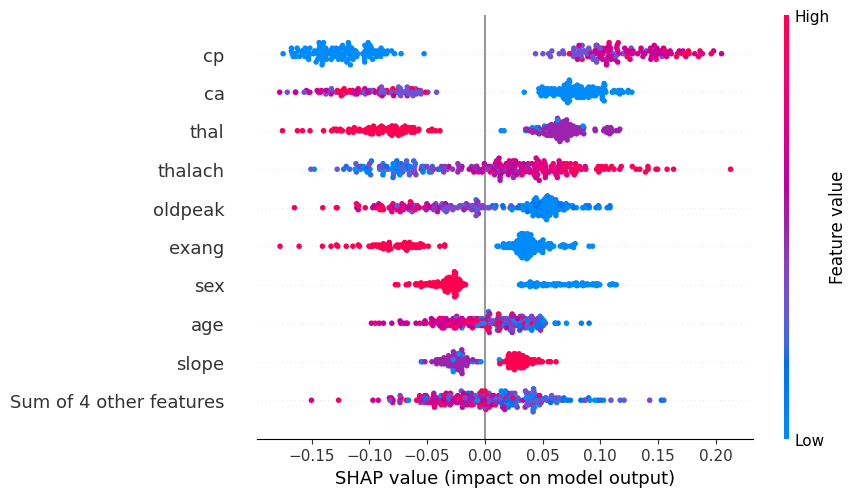

In [20]:
shap.initjs()

explainer = shap.Explainer(model)
shap_values = explainer(X_train)

print(f"\nSHAP values shape: {shap_values.shape}")
print(f"Expected shape: (n_samples, n_features, n_classes)")

shap.plots.beeswarm(shap_values[:, :, 1], show=False)

In [21]:
joblib.dump(model, "heart_risk_model.pkl")
files.download("heart_risk_model.pkl")

print("\n✅ Process Complete! Model ready for clinical use.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Process Complete! Model ready for clinical use.


<Figure size 640x480 with 0 Axes>

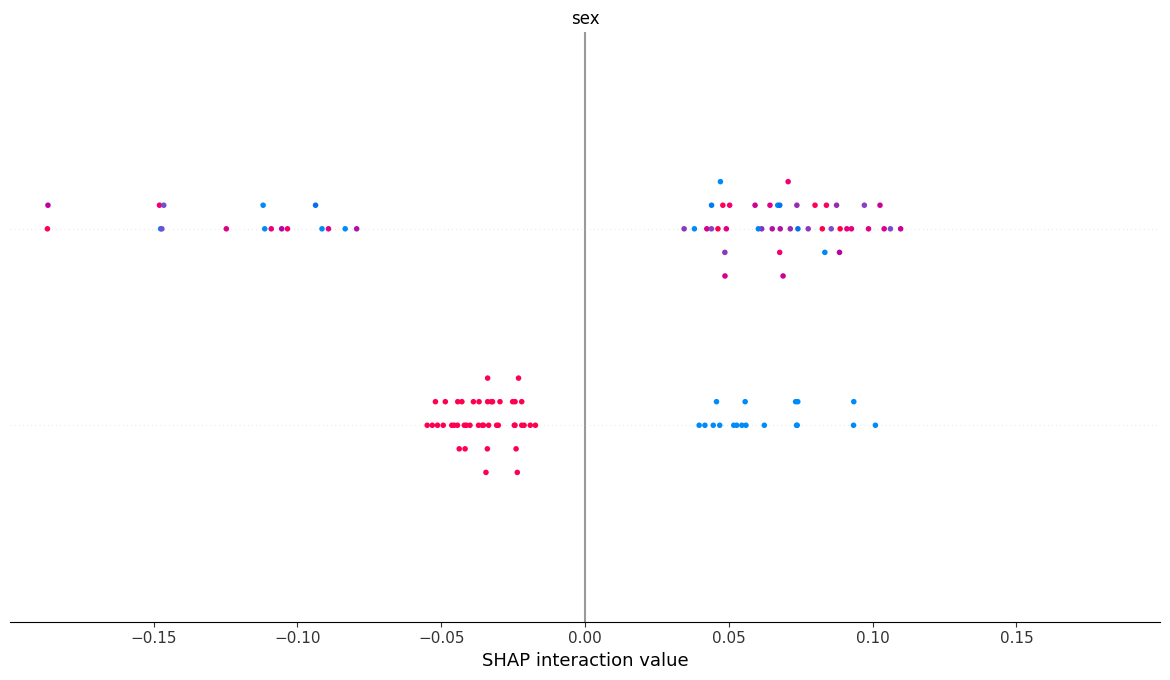

In [22]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [23]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [100, 200], 'max_depth': [5, 10]}
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              max_depth=7, n_estimators=150,
                                              random_state=42),
             param_grid={'max_depth': [5, 10], 'n_estimators': [100, 200]})

In [25]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)  # ← Use test data for honest explanations